<a href="https://colab.research.google.com/github/Chalhotra/ViT-Token-Economy/blob/priyanshu%2Fprogressive-testing/notebooks/01_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baselines: DeiT and ViT Family (ImageNet-100)

This notebook follows the same structure as the EViT/ToMe notebooks:
- Shared utility plotting functions
- Explicit per-model run cells
- Final multi-model comparison visualizations

Models covered in this baseline notebook:
- DeiT-Tiny, DeiT-Small, DeiT-Base
- ViT-Tiny, ViT-Small, ViT-Base

In [1]:
# If running in a fresh Colab runtime, uncomment these lines:
!git clone https://github.com/Chalhotra/ViT-Token-Economy.git
%cd ViT-Token-Economy

Cloning into 'ViT-Token-Economy'...
remote: Enumerating objects: 411, done.
remote: Counting objects: 100% (190/190), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 411 (delta 122), reused 122 (delta 73), pack-reused 221 (from 1)
Receiving objects: 100% (411/411), 2.13 MiB | 9.10 MiB/s, done.
Resolving deltas: 100% (245/245), done.
/content/ViT-Token-Economy


In [2]:
!git checkout priyanshu/progressive-testing

Branch 'priyanshu/progressive-testing' set up to track remote branch 'priyanshu/progressive-testing' from 'origin'.
Switched to a new branch 'priyanshu/progressive-testing'


In [3]:
!pip -q install -r requirements.txt
!pip -q install -e .

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for vit-deit-baselines (pyproject.toml) ... done


In [4]:
from src.imagenet_mapping import build_imagenet100_to_1k_map
from src.models import ModelConfig, create_model, shrink_imagenet1k_head_to_imagenet100
from src.data import DataConfig, load_imagenet100_split, build_transform_for_model, apply_timm_preprocess, build_loader
from src.eval import evaluate_accuracy_latency_throughput, compute_gflops
from src.utils import get_device, num_params

In [5]:
device = get_device()
maps = build_imagenet100_to_1k_map()

In [17]:
import pandas as pd
from IPython.display import display

# Similar table-style visualization for baseline runs
if 'baseline_results' in globals() and baseline_results:
    df_baseline = pd.DataFrame(baseline_results).copy()
elif 'results' in globals() and results:
    df_all = pd.DataFrame(results).copy()

    # fallback: try to infer baseline rows from common naming patterns
    if 'config_name' in df_all.columns:
        mask = (
            ~df_all['config_name'].str.startswith('ToMe ', na=False)
            & ~df_all['config_name'].str.startswith('EViT ', na=False)
            & ~df_all['config_name'].str.contains('TopK', na=False)
            & ~df_all['config_name'].str.contains('Random', na=False)
            & ~df_all['config_name'].str.contains('prun', case=False, na=False)
            & ~df_all['config_name'].str.contains('merge', case=False, na=False)
        )
        df_baseline = df_all[mask].copy()
    else:
        df_baseline = pd.DataFrame()
else:
    df_baseline = pd.DataFrame()

if df_baseline.empty:
    print("No baseline results found yet. Run the baseline cells first.")
else:
    # Ensure numeric columns are numeric
    for col in ['acc1', 'latency_ms', 'throughput', 'gflops', 'params_m']:
        if col in df_baseline.columns:
            df_baseline[col] = pd.to_numeric(df_baseline[col], errors='coerce')

    # If model column is missing, try to extract/infer it
    if 'model' not in df_baseline.columns:
        if 'config_name' in df_baseline.columns:
            df_baseline['model'] = df_baseline['config_name']
        else:
            df_baseline['model'] = [f"model_{i}" for i in range(len(df_baseline))]

    # Optional pretty rounding
    round_map = {
        'acc1': 2,
        'latency_ms': 3,
        'throughput': 3,
        'gflops': 3,
        'params_m': 3,
    }
    for col, digits in round_map.items():
        if col in df_baseline.columns:
            df_baseline[col] = df_baseline[col].round(digits)

    # Sort by model name
    df_baseline = df_baseline.sort_values(['model']).reset_index(drop=True)

    cols = [
        c for c in [
            'model',
            'config_name',
            'acc1',
            'latency_ms',
            'throughput',
            'gflops',
            'params_m',
        ] if c in df_baseline.columns
    ]

    display(df_baseline[cols])

No baseline results found yet. Run the baseline cells first.


## Utility Functions for Baseline Visualization

In [7]:
def run_baseline_test(model_id: str, batch_size: int = 64):
    print(f"\n{'='*80}")
    print(f"Testing baseline model: {model_id}")
    print(f"{'='*80}\n")

    model = create_model(ModelConfig(model_id=model_id, pretrained=True))
    model = shrink_imagenet1k_head_to_imagenet100(model, maps.new_to_old_map, num_classes=100)
    model = model.to(device).eval()

    ds = load_imagenet100_split(DataConfig(split='validation'))
    transform = build_transform_for_model(model)
    ds_t = apply_timm_preprocess(ds, transform)
    loader = build_loader(ds_t, DataConfig(batch_size=batch_size, split='validation', shuffle=False))

    metrics = evaluate_accuracy_latency_throughput(model, loader, device)
    sample = ds_t[0]['pixel_values'].unsqueeze(0).to(device)
    gflops = compute_gflops(model, sample)

    result = {
        'model': model_id,
        'params_m': num_params(model) / 1e6,
        'gflops': gflops,
        **metrics,
    }

    print(f"Results for {model_id}:")
    print(f"  Top-1 Accuracy: {metrics['acc1']:.2f}%")
    print(f"  GFLOPs: {gflops:.3f}")
    print(f"  Latency: {metrics['latency_ms']:.2f} ms")
    print(f"  Throughput: {metrics['throughput']:.1f} samples/sec")

    return result

In [8]:
# Baseline: DeiT-Tiny
if 'results' not in globals():
    results = []

name = 'deit_tiny_patch16_224'
results = [x for x in results if x.get('model') != name]
results.append(run_baseline_test(name))


Testing baseline model: deit_tiny_patch16_224



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

...

Generating train split:   0%|          | 0/126689 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop


Results for deit_tiny_patch16_224:
  Top-1 Accuracy: 88.42%
  GFLOPs: 1.079
  Latency: 1.63 ms
  Throughput: 613.9 samples/sec


In [9]:
# Baseline: DeiT-Small
if 'results' not in globals():
    results = []

name = 'deit_small_patch16_224'
results = [x for x in results if x.get('model') != name]
results.append(run_baseline_test(name))


Testing baseline model: deit_small_patch16_224



model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop


Results for deit_small_patch16_224:
  Top-1 Accuracy: 92.62%
  GFLOPs: 4.250
  Latency: 3.09 ms
  Throughput: 323.5 samples/sec


In [10]:
# Baseline: DeiT-Base
if 'results' not in globals():
    results = []

name = 'deit_base_patch16_224'
results = [x for x in results if x.get('model') != name]
results.append(run_baseline_test(name))


Testing baseline model: deit_base_patch16_224



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop


Results for deit_base_patch16_224:
  Top-1 Accuracy: 93.64%
  GFLOPs: 16.867
  Latency: 12.77 ms
  Throughput: 78.3 samples/sec


In [11]:
# Baseline: ViT-Tiny
if 'results' not in globals():
    results = []

name = 'vit_tiny_patch16_224'
results = [x for x in results if x.get('model') != name]
results.append(run_baseline_test(name))


Testing baseline model: vit_tiny_patch16_224



model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop


Results for vit_tiny_patch16_224:
  Top-1 Accuracy: 89.22%
  GFLOPs: 1.079
  Latency: 1.32 ms
  Throughput: 756.2 samples/sec


In [12]:
# Baseline: ViT-Small
if 'results' not in globals():
    results = []

name = 'vit_small_patch16_224'
results = [x for x in results if x.get('model') != name]
results.append(run_baseline_test(name))


Testing baseline model: vit_small_patch16_224



model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop


Results for vit_small_patch16_224:
  Top-1 Accuracy: 93.18%
  GFLOPs: 4.250
  Latency: 3.44 ms
  Throughput: 290.7 samples/sec


In [13]:
# Baseline: ViT-Base
if 'results' not in globals():
    results = []

name = 'vit_base_patch16_224'
results = [x for x in results if x.get('model') != name]
results.append(run_baseline_test(name))


Testing baseline model: vit_base_patch16_224



model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop


Results for vit_base_patch16_224:
  Top-1 Accuracy: 95.52%
  GFLOPs: 16.867
  Latency: 12.72 ms
  Throughput: 78.6 samples/sec


In [19]:
# Final combined comparison table for all baseline models
if 'results' not in globals() or not results:
    print('No baseline results found. Run one or more baseline model cells first.')
else:
    df_all = pd.DataFrame(results).copy()

    if not df_all.empty:
        df_all = df_all.sort_values('model')

        cols = [
            c for c in [
                'model', 'acc1', 'latency_ms', 'throughput', 'gflops', 'params_m'
            ] if c in df_all.columns
        ]
        display(df_all[cols].reset_index(drop=True))
    else:
        print('No baseline results found. Run one or more baseline model cells first.')

,model,acc1,latency_ms,throughput,gflops,params_m
0,deit_base_patch16_224,93.64,12.771887,78.296966,16.866722,85.875556
1,deit_small_patch16_224,92.62,3.091560,323.461324,4.250329,21.704164
2,deit_tiny_patch16_224,88.42,1.628874,613.921077,1.079407,5.543716
3,vit_base_patch16_224,95.52,12.720623,78.612502,16.866722,85.875556
4,vit_small_patch16_224,93.18,3.439883,290.707532,4.250329,21.704164
5,vit_tiny_patch16_224,89.22,1.322366,756.220110,1.079407,5.543716


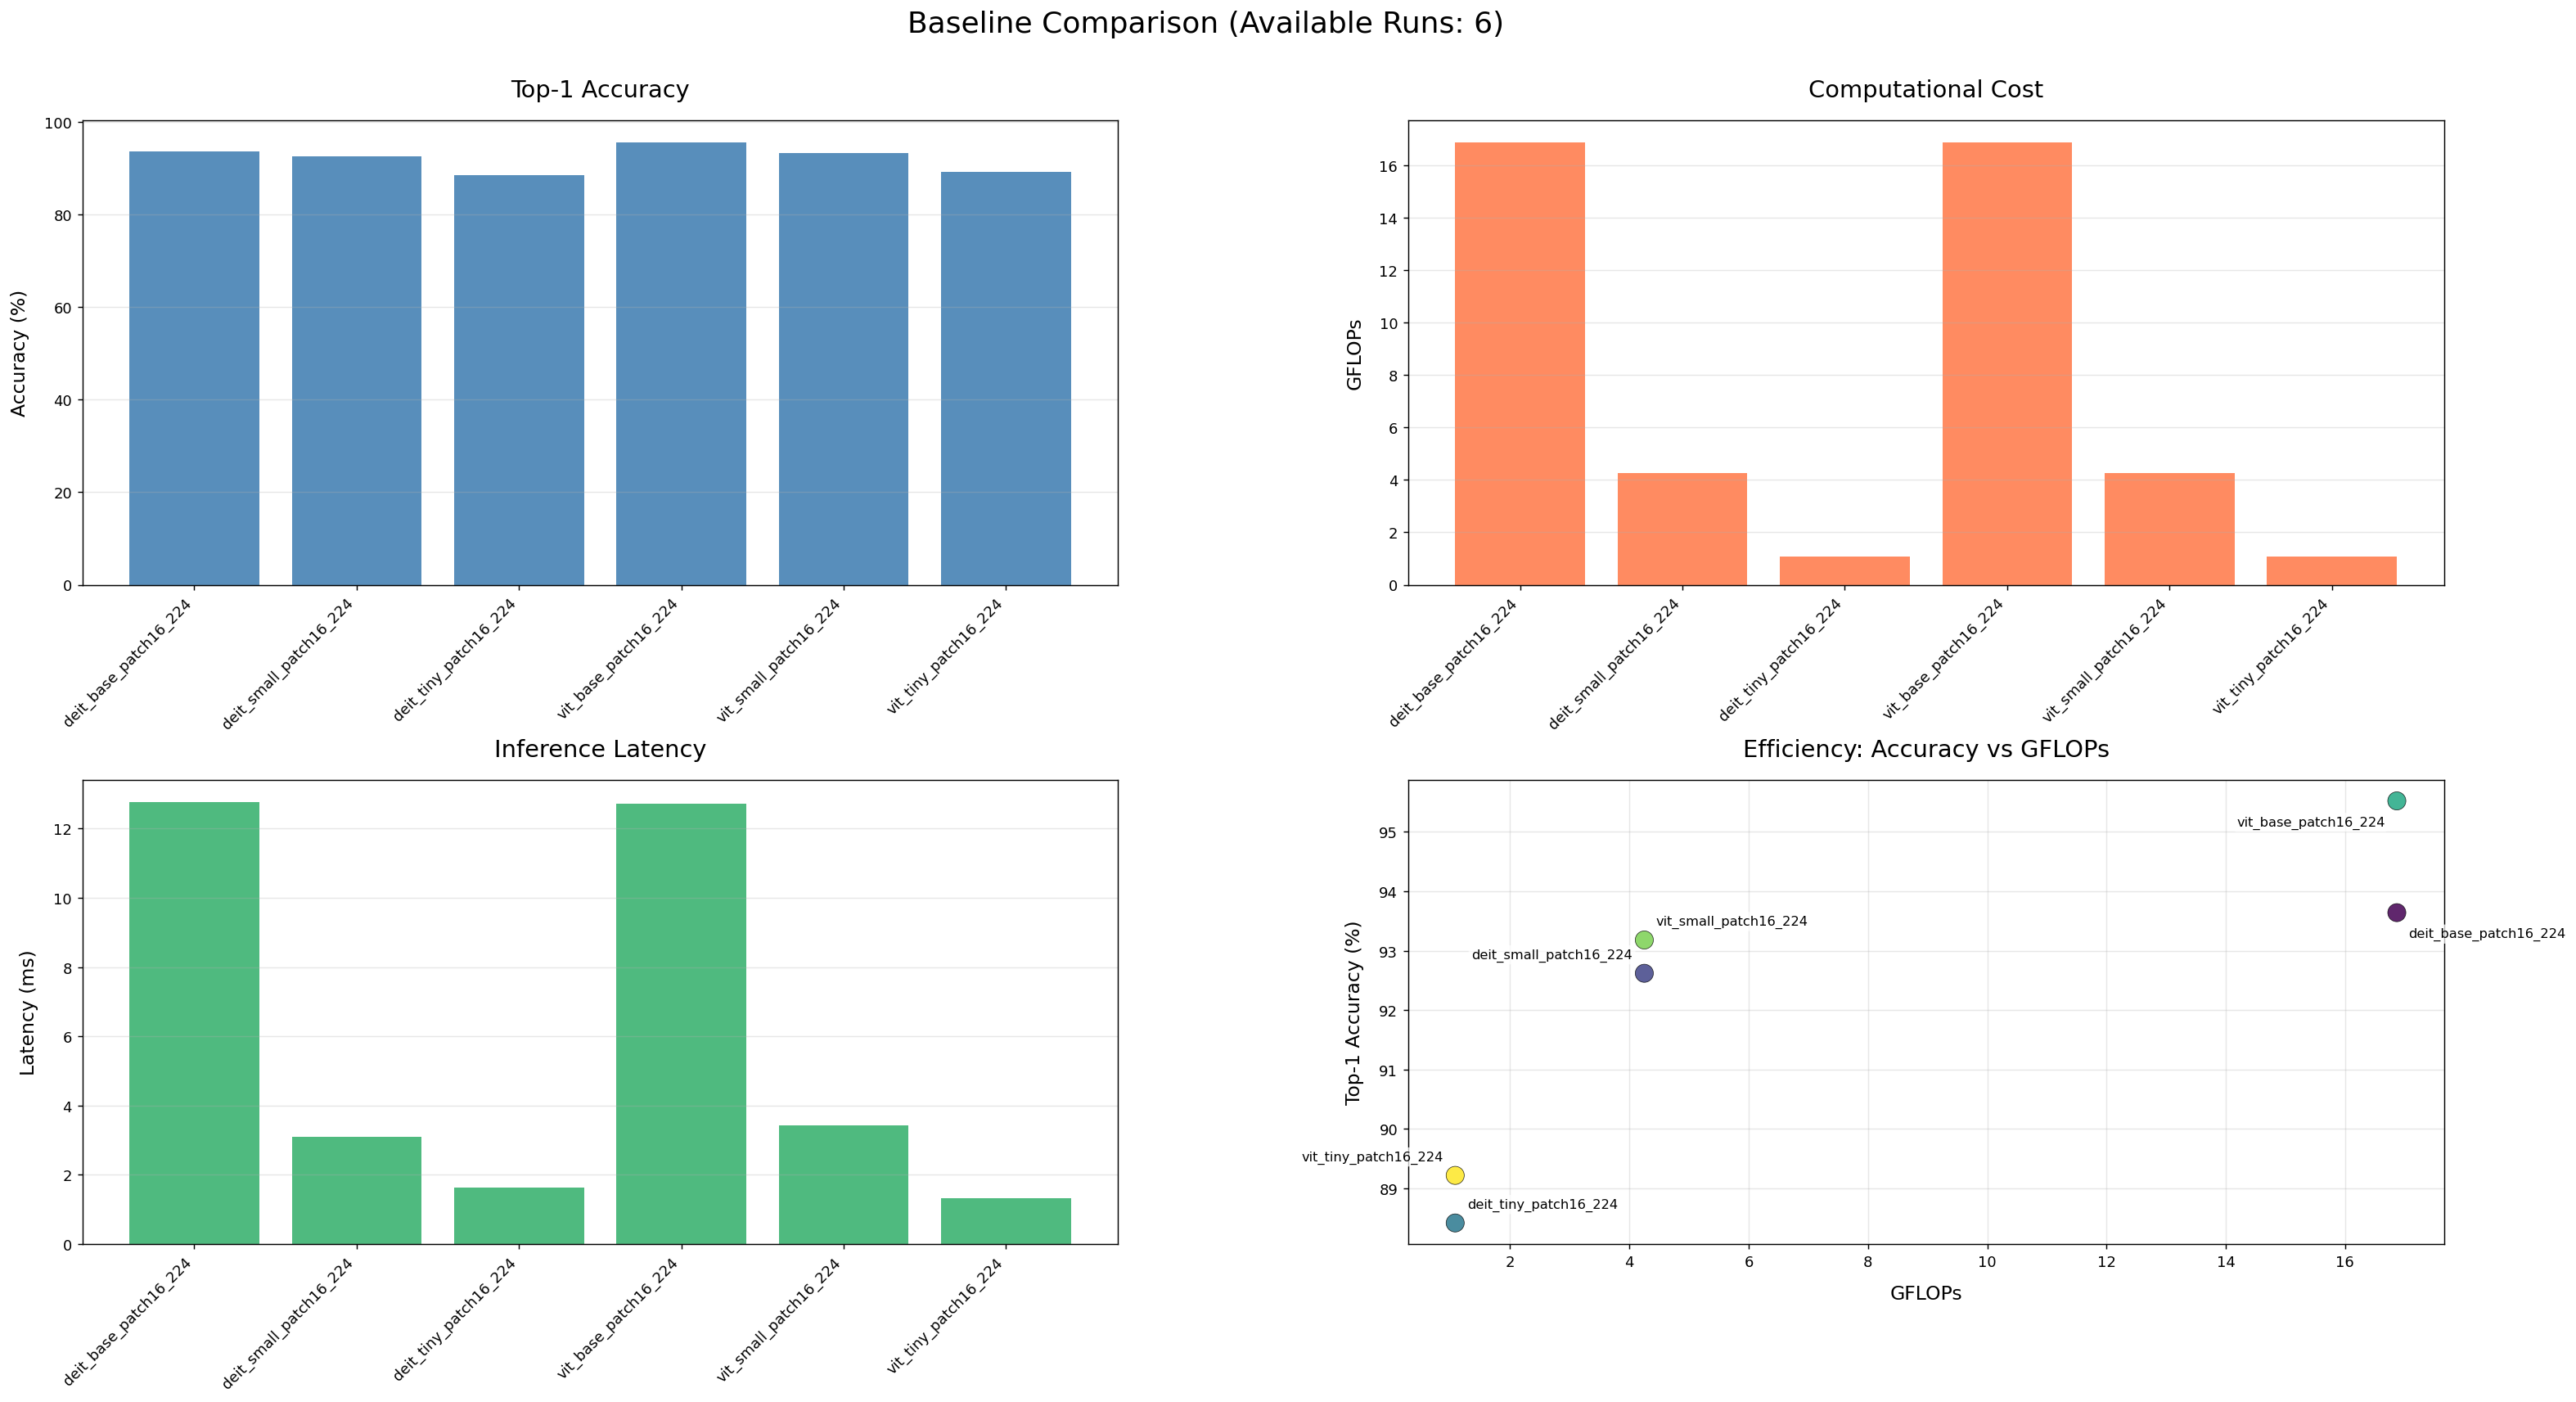


Baseline Comparison (Available Runs: 6) – Summary Table
                 model  params_m    gflops  acc1  latency_ms  throughput
 deit_base_patch16_224 85.875556 16.866722 93.64   12.771887   78.296966
deit_small_patch16_224 21.704164  4.250329 92.62    3.091560  323.461324
 deit_tiny_patch16_224  5.543716  1.079407 88.42    1.628874  613.921077
  vit_base_patch16_224 85.875556 16.866722 95.52   12.720623   78.612502
 vit_small_patch16_224 21.704164  4.250329 93.18    3.439883  290.707532
  vit_tiny_patch16_224  5.543716  1.079407 89.22    1.322366  756.220110



In [18]:
# Final baseline visualization call (works with any subset of models already run)
if 'results' not in globals() or not results:
    print('No baseline results found. Run one or more baseline model cells first.')
else:
    compare_baseline_models_spacious(
        results,
        title=f'Baseline Comparison (Available Runs: {len(results)})'
    )